# LokaSense Training Notebook

This is the maintained end-to-end training path for the repo.
It is public-scrape first, free-by-default, and writes the outputs directly into notebook cells.


## Notebook Flow

1. Validate the environment and the notebook safety switches.
2. Reuse existing public scrape data or refresh the public social sources if the local corpora are too small.
3. Run EDA on source mix and language mix.
4. Rebuild `signal_bootstrap.csv` and `ner_bootstrap.jsonl`.
5. Generate weak labels and optional Gemini augmentation.
6. Create leakage-safe train, validation, and test splits.
7. Train and evaluate the signal model and the NER model.
8. Run production-style opportunity scoring and write a readiness summary.


In [1]:
import json
import os
import platform
import re
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from dotenv import load_dotenv
from IPython.display import display

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "01_data_collection").exists(), "Please run this notebook from the repo root."
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SPATIAL_MODELLING_DIR = REPO_ROOT / "04_spatial_engine" / "modelling"
if str(SPATIAL_MODELLING_DIR) not in sys.path:
    sys.path.insert(0, str(SPATIAL_MODELLING_DIR))

import scoring as spatial_scoring
import heatmap as spatial_heatmap

from common.bootstrap_utils import build_ner_bootstrap_rows, build_signal_bootstrap_rows
from common.location_resolution import LocationResolver
from common.text_normalization import language_scores, strip_emoji

load_dotenv(REPO_ROOT / ".env")

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

SCRAPING_PYTHON = REPO_ROOT / ".venv_scraping" / "bin" / "python"
SOCIAL_SOURCE_FILES = {
    "tiktok": REPO_ROOT / "data" / "social_media" / "tiktok_data.csv",
    "instagram": REPO_ROOT / "data" / "social_media" / "instagram_data.csv",
    "x": REPO_ROOT / "data" / "social_media" / "x_data.csv",
}


def count_existing_rows(path: Path) -> int:
    if not path.exists():
        return 0
    try:
        df = pd.read_csv(path)
        return int(len(df))
    except Exception:
        return 0


SOCIAL_REFRESH_SPECS = [
    {
        "platform": "tiktok",
        "source_file": SOCIAL_SOURCE_FILES["tiktok"],
        "min_rows": int(os.getenv("NOTEBOOK_MIN_TIKTOK_ROWS", "220")),
        "max_queries": int(os.getenv("NOTEBOOK_TIKTOK_MAX_QUERIES", "180")),
        "max_saved_rows": int(os.getenv("NOTEBOOK_TIKTOK_MAX_ROWS", "240")),
    },
    {
        "platform": "instagram",
        "source_file": SOCIAL_SOURCE_FILES["instagram"],
        "min_rows": int(os.getenv("NOTEBOOK_MIN_INSTAGRAM_ROWS", "80")),
        "max_queries": int(os.getenv("NOTEBOOK_INSTAGRAM_MAX_QUERIES", "120")),
        "max_saved_rows": int(os.getenv("NOTEBOOK_INSTAGRAM_MAX_ROWS", "100")),
    },
    {
        "platform": "x",
        "source_file": SOCIAL_SOURCE_FILES["x"],
        "min_rows": int(os.getenv("NOTEBOOK_MIN_X_ROWS", "80")),
        "max_queries": int(os.getenv("NOTEBOOK_X_MAX_QUERIES", "120")),
        "max_saved_rows": int(os.getenv("NOTEBOOK_X_MAX_ROWS", "100")),
    },
]
for spec in SOCIAL_REFRESH_SPECS:
    spec["existing_rows"] = count_existing_rows(spec["source_file"])

FORCE_SOCIAL_REFRESH = os.getenv("FORCE_NOTEBOOK_SOCIAL_REFRESH", "0") == "1"
SOCIAL_REFRESH_PLAN = [
    spec
    for spec in SOCIAL_REFRESH_SPECS
    if FORCE_SOCIAL_REFRESH or int(spec["existing_rows"]) < int(spec["min_rows"])
]
INCLUDE_GOOGLE_MAPS_CACHE = os.getenv("INCLUDE_GMAPS_CACHE", "0") == "1"
RUN_GEMINI_AUGMENTATION = os.getenv("ENABLE_NOTEBOOK_GEMINI", "0") == "1"
GEMINI_MAX_SAMPLES = int(os.getenv("NOTEBOOK_GEMINI_MAX_SAMPLES", "1200"))
FORCE_GEMINI_REFRESH = os.getenv("FORCE_NOTEBOOK_GEMINI_REFRESH", "0") == "1"
RUN_MODEL_PSEUDOLABEL = os.getenv("ENABLE_NOTEBOOK_MODEL_PSEUDOLABEL", "0") == "1"
MODEL_PSEUDOLABEL_MAX_SAMPLES = int(os.getenv("NOTEBOOK_MODEL_PSEUDOLABEL_MAX_SAMPLES", "600"))
FORCE_MODEL_PSEUDOLABEL_REFRESH = os.getenv("FORCE_NOTEBOOK_MODEL_PSEUDOLABEL_REFRESH", "0") == "1"
GOOGLE_MAPS_REFRESH_REQUESTED = os.getenv("ENABLE_GOOGLE_MAPS_REFRESH", "0") == "1"
if GOOGLE_MAPS_REFRESH_REQUESTED:
    print("Notebook keeps Google Maps refresh disabled. Run collect_gmaps_reviews.py --confirm-billable manually if you truly need it.")

def build_social_refresh_args(spec: dict[str, object]) -> list[str]:
    return [
        str(SCRAPING_PYTHON if SCRAPING_PYTHON.exists() else Path(sys.executable)),
        "01_data_collection/collect_social_bootstrap.py",
        "--platform",
        str(spec["platform"]),
        "--max-queries",
        str(spec["max_queries"]),
        "--max-per-query",
        "8",
        "--max-saved-rows",
        str(spec["max_saved_rows"]),
        "--headless",
        "--query-delay",
        "0.6",
    ]

SIGNAL_LABELS = [
    "NEUTRAL",
    "DEMAND_UNMET",
    "DEMAND_PRESENT",
    "SUPPLY_SIGNAL",
    "COMPETITION_HIGH",
    "COMPLAINT",
    "TREND",
]

READINESS_THRESHOLDS = {
    "signal_train_rows": 300,
    "signal_eval_macro_f1": 0.55,
    "signal_gold_macro_f1": 0.50,
    "ner_eval_micro_f1": 0.75,
    "opportunity_groups": 5,
}
MANUAL_SIGNAL_TEST_FILE = REPO_ROOT / "test_data" / "signal_test_manual.csv"


def run_command(args, cwd=REPO_ROOT, extra_env=None):
    env = os.environ.copy()
    if extra_env:
        env.update(extra_env)
    print("$", " ".join(map(str, args)))
    completed = subprocess.run(
        args,
        cwd=str(cwd),
        env=env,
        text=True,
        capture_output=True,
        check=False,
    )
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {completed.returncode}: {' '.join(map(str, args))}")
    return completed


def classify_language(text: str) -> str:
    scores = language_scores(str(text))
    id_score = scores["id"] + scores["slang"]
    en_score = scores["en"]
    if id_score == 0 and en_score == 0:
        return "unclear"
    if id_score >= en_score:
        return "indonesian_dominant"
    return "english_dominant"


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def clean_preview_frame(df: pd.DataFrame) -> pd.DataFrame:
    preview = df.copy()
    for column in preview.columns:
        if pd.api.types.is_object_dtype(preview[column]):
            preview[column] = preview[column].fillna("").astype(str).map(strip_emoji)
    return preview


def reset_social_artifacts(platform: str) -> None:
    for path in [
        REPO_ROOT / "data" / "social_media" / f"{platform}_data.csv",
        REPO_ROOT / "data" / "scraped" / "checkpoints" / f"{platform}_crawl_state.json",
    ]:
        if path.exists():
            path.unlink()
            print(f"Removed {path}")


def validate_scraping_runtime():
    scrape_python = Path(SCRAPING_PYTHON if SCRAPING_PYTHON.exists() else Path(sys.executable))
    if not scrape_python.exists():
        raise FileNotFoundError(f"Scraping Python runtime not found at {scrape_python}")
    probe = subprocess.run(
        [str(scrape_python), "-c", "import scrapling; print(scrapling.__version__)"],
        cwd=str(REPO_ROOT),
        text=True,
        capture_output=True,
        check=False,
    )
    if probe.returncode != 0:
        raise RuntimeError(probe.stderr or probe.stdout or "Failed to validate Scrapling runtime")
    print(f"Scraping runtime ready: {scrape_python}")


environment_summary = {
    "python_executable": sys.executable,
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu_only",
    "social_rows": json.dumps({spec["platform"]: spec["existing_rows"] for spec in SOCIAL_REFRESH_SPECS}, ensure_ascii=False),
    "social_min_rows": json.dumps({spec["platform"]: spec["min_rows"] for spec in SOCIAL_REFRESH_SPECS}, ensure_ascii=False),
    "social_refresh_plan": json.dumps([spec["platform"] for spec in SOCIAL_REFRESH_PLAN], ensure_ascii=False),
    "include_google_maps_cache": INCLUDE_GOOGLE_MAPS_CACHE,
    "run_gemini_augmentation": RUN_GEMINI_AUGMENTATION,
    "gemini_max_samples": GEMINI_MAX_SAMPLES,
    "google_maps_refresh_disabled": True,
}
display(pd.DataFrame([environment_summary]))


,python_executable,python_version,platform,torch_version,cuda_available,cuda_device,social_rows,social_min_rows,social_refresh_plan,include_google_maps_cache,run_gemini_augmentation,gemini_max_samples,google_maps_refresh_disabled
0,/home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python,3.14.3,Linux-6.12.52_1-x86_64-with-glibc2.41,2.11.0+cu130,True,NVIDIA GeForce RTX 4050 Laptop GPU,"{""tiktok"": 348, ""instagram"": 0, ""x"": 0}","{""tiktok"": 220, ""instagram"": 80, ""x"": 80}","[""instagram"", ""x""]",False,False,1200,True


The setup cell shows the exact execution mode up front.
Google Maps refresh is intentionally disabled here, and Gemini augmentation is opt-in through an environment variable instead of being silently baked into the notebook.


In [2]:
raw_files = {
    **SOCIAL_SOURCE_FILES,
    "google_maps": REPO_ROOT / "data" / "social_media" / "gmaps_reviews.csv",
}

if SOCIAL_REFRESH_PLAN:
    validate_scraping_runtime()
    for spec in SOCIAL_REFRESH_PLAN:
        if FORCE_SOCIAL_REFRESH:
            reset_social_artifacts(str(spec["platform"]))
        print(
            f"Refreshing {spec['platform']} because rows={spec['existing_rows']} "
            f"< min_rows={spec['min_rows']}"
        )
        run_command(build_social_refresh_args(spec))
else:
    print("Skipping public social refresh and reusing the current raw CSV files.")

raw_counts = []
for source, path in raw_files.items():
    if path.exists():
        df = pd.read_csv(path)
        raw_counts.append({"source": source, "rows": len(df), "path": str(path)})
raw_counts_df = pd.DataFrame(raw_counts).sort_values("rows", ascending=False)
display(raw_counts_df)


Scraping runtime ready: /home/parasite/Project/Competition/UGM_HACKATHON/.venv_scraping/bin/python
Refreshing instagram because rows=0 < min_rows=80
$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv_scraping/bin/python 01_data_collection/collect_social_bootstrap.py --platform instagram --max-queries 120 --max-per-query 8 --max-saved-rows 100 --headless --query-delay 0.6


 Scrapling Social Bootstrap Collection Complete
  google_maps  rows= 5110 blocked=0
  instagram    rows=    0 blocked=120
  signal_bootstrap: 361
  ner_bootstrap   : 361
  manifest        : /home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/manifest.json

(node:24862) Warning: The 'NO_COLOR' env is ignored due to the 'FORCE_COLOR' env being set.
(Use `node --trace-warnings ...` to show where the warning was created)
[2026-04-12 22:25:32] INFO: Fetched (200) <GET https://www.bing.com/search?q=site%3Ainstagram.com+kedai+kopi+mahal+banget+Sukun+Malang> (referer: https://www.google.com/)
[2026-04-12 22:25:32] INFO: Fetched (200) <GET https://www.bing.com/search?q=site%3Ainstagram.com+bakso+gak+worth+it+Lowokwaru+Malang> (referer: https://www.google.com/)
[2026-04-12 22:25:32] INFO: Fetched (200) <GET https://www.bing.com/search?q=site%3Ainstagram.com+cafe+pelayanan+lama+Wonokromo+Surabaya> (referer: https://www.google.com/)
[2026-04-12 22:25:32] INFO: Fetched (200) <GET https://

 Scrapling Social Bootstrap Collection Complete
  google_maps  rows= 5110 blocked=0
  x            rows=    0 blocked=120
  signal_bootstrap: 361
  ner_bootstrap   : 361
  manifest        : /home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/manifest.json

(node:25371) Warning: The 'NO_COLOR' env is ignored due to the 'FORCE_COLOR' env being set.
(Use `node --trace-warnings ...` to show where the warning was created)
[2026-04-12 22:26:02] INFO: Fetched (200) <GET https://www.bing.com/search?q=site%3Ax.com+kedai+kopi+mahal+banget+Sukun+Malang> (referer: https://www.google.com/)
[2026-04-12 22:26:02] INFO: Fetched (200) <GET https://www.bing.com/search?q=site%3Atwitter.com+kedai+kopi+mahal+banget+Sukun+Malang> (referer: https://www.google.com/)
[2026-04-12 22:26:02] INFO: Fetched (200) <GET https://www.bing.com/search?q=site%3Ax.com+bakso+gak+worth+it+Lowokwaru+Malang> (referer: https://www.google.com/)
[2026-04-12 22:26:02] INFO: Fetched (200) <GET https://www.bing.com/search?

,source,rows,path
1,google_maps,5110,/home/parasite/Project/Competition/UGM_HACKATHON/data/social_media/gmaps_reviews.csv
0,tiktok,348,/home/parasite/Project/Competition/UGM_HACKATHON/data/social_media/tiktok_data.csv


The notebook refreshes only the public social sources that are below their configured row thresholds.
That keeps reruns practical while still giving the complaint and review-heavy platforms a chance to contribute when they are missing.


,source,rows,non_empty_text_rows,avg_text_length,indonesian_dominant,english_dominant,unclear
1,google_maps,5110,5110,244.9,79,4835,196
0,tiktok,348,348,106.3,348,0,0


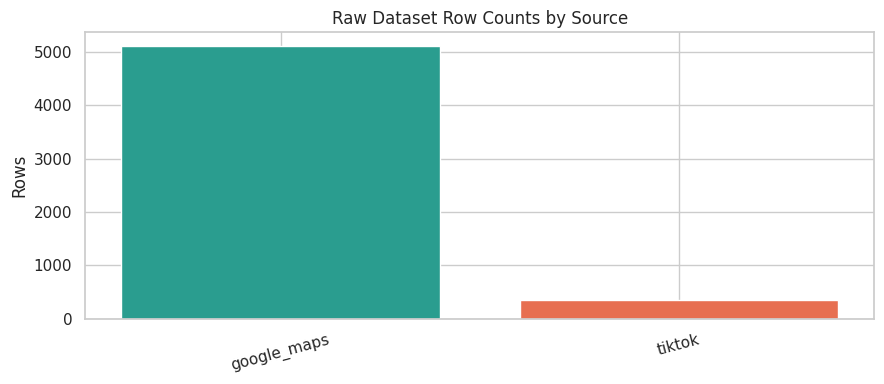

,source,text,city,area_hint,business_hint,query
0,tiktok,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free es teh loh. yuk merapat! malang kuliner...",Malang,Lowokwaru,mie,mie buka cabang di lowokwaru malang
1,tiktok,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free es teh loh.",Malang,Lowokwaru,mie,mie buka cabang di lowokwaru malang
2,tiktok,sudah pada nyobain guys kuliner malang kulinermalang bakmi mie,Malang,Lowokwaru,mie,mie buka cabang di lowokwaru malang
3,google_maps,"I'm sorry but I'm so not impressed.\nMy chicken is cold, batter is stoney, can't really taste the chicken meat.\nRice is soft, but cold.\nThey forgot my ice...",Malang,Lowokwaru,ayam geprek,NaN
4,google_maps,"It was okay but not great. I ordered sambal matah variant and they gave me a full bowl (small bowl) of sambal matah, that's a plus point. But the rice is ta...",Malang,Lowokwaru,ayam geprek,NaN
5,google_maps,The food taste good with several options for sambal. The place is quite small so i don't recommend to come with large group. It is easy to notice from the r...,Malang,Lowokwaru,ayam geprek,NaN


In [3]:
eda_rows = []
sample_frames = []

for source, path in raw_files.items():
    if not path.exists():
        continue

    df = pd.read_csv(path)
    text_col = "raw_text" if "raw_text" in df.columns else "text"
    texts = df[text_col].fillna("").astype(str)
    language_mix = Counter(classify_language(text) for text in texts if text.strip())

    eda_rows.append(
        {
            "source": source,
            "rows": len(df),
            "non_empty_text_rows": int((texts.str.len() > 0).sum()),
            "avg_text_length": round(float(texts.str.len().mean()), 1),
            "indonesian_dominant": language_mix.get("indonesian_dominant", 0),
            "english_dominant": language_mix.get("english_dominant", 0),
            "unclear": language_mix.get("unclear", 0),
        }
    )

    preview_cols = [col for col in ["text", "city", "area_hint", "business_hint", "query"] if col in df.columns]
    if preview_cols:
        preview = clean_preview_frame(df[preview_cols].head(3).copy())
        preview.insert(0, "source", source)
        sample_frames.append(preview)

eda_df = pd.DataFrame(eda_rows).sort_values("rows", ascending=False)
display(eda_df)

plt.figure(figsize=(9, 4))
plt.bar(eda_df["source"], eda_df["rows"], color=["#2a9d8f", "#e76f51", "#f4a261", "#457b9d"][: len(eda_df)])
plt.title("Raw Dataset Row Counts by Source")
plt.ylabel("Rows")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

if sample_frames:
    display(pd.concat(sample_frames, ignore_index=True))


This is the first hard sanity check.
If the Indonesian share is too small or the source mix is dominated by irrelevant text, the rest of the notebook will faithfully expose that problem instead of hiding it behind a headline metric.


In [4]:
signal_rows = build_signal_bootstrap_rows(include_google_maps=INCLUDE_GOOGLE_MAPS_CACHE)
signal_bootstrap_df = pd.DataFrame(signal_rows)
signal_bootstrap_path = REPO_ROOT / "data" / "scraped" / "signal_bootstrap.csv"
signal_bootstrap_df.to_csv(signal_bootstrap_path, index=False)

ner_rows = build_ner_bootstrap_rows(signal_rows)
ner_bootstrap_path = REPO_ROOT / "data" / "scraped" / "ner_bootstrap.jsonl"
ner_bootstrap_path.parent.mkdir(parents=True, exist_ok=True)
with open(ner_bootstrap_path, "w", encoding="utf-8") as handle:
    for row in ner_rows:
        handle.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"signal_bootstrap_path = {signal_bootstrap_path}")
print(f"ner_bootstrap_path = {ner_bootstrap_path}")
print(f"signal_rows = {len(signal_bootstrap_df)}")
print(f"ner_rows = {len(ner_rows)}")

if not signal_bootstrap_df.empty:
    display(clean_preview_frame(signal_bootstrap_df.head(10)))
    display(
        signal_bootstrap_df.groupby(["platform", "city"])["text"].count().rename("rows").reset_index().sort_values("rows", ascending=False)
    )

candidate_counts = [len(row["candidate_spans"]) for row in ner_rows]
display(
    pd.DataFrame(
        {
            "candidate_span_min": [int(np.min(candidate_counts)) if candidate_counts else 0],
            "candidate_span_mean": [round(float(np.mean(candidate_counts)), 2) if candidate_counts else 0.0],
            "candidate_span_max": [int(np.max(candidate_counts)) if candidate_counts else 0],
        }
    )
)


signal_bootstrap_path = /home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/signal_bootstrap.csv
ner_bootstrap_path = /home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/ner_bootstrap.jsonl
signal_rows = 361
ner_rows = 361


,text,source,platform,url,timestamp,area_hint,city,business_hint,query,query_intent,provenance_split
0,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free es teh loh. yuk merapat! malang kuliner...",tiktok_scrapling,tiktok,https://www.tiktok.com/@mieayamkeraton/video/7624395493249993991,2026-04-03T05:08:39Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,train
1,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free es teh loh.",tiktok_scrapling,tiktok,https://www.tiktok.com/@mieayamkeraton/video/7624395493249993991,2026-04-03T05:08:39Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,train
2,sudah pada nyobain guys kuliner malang kulinermalang bakmi mie,tiktok_scrapling,tiktok,https://www.tiktok.com/@mbakbulekulineran/video/7539804950214364422,2025-08-18T06:14:14Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,test
3,jangan lebay tapi ini mala nya balance kuliner malang kulinermalang mie noodles mala pedas spicy mbakbulekulineran,tiktok_scrapling,tiktok,https://www.tiktok.com/@mbakbulekulineran/video/7505634284594531590,2025-05-18T04:14:29Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,test
4,mia ayam langganan siapa nih kuliner malang kulinermalang mie mieayam,tiktok_scrapling,tiktok,https://www.tiktok.com/@mbakbulekulineran/video/7589989139756354834,2025-12-31T11:54:20Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,train
5,mia ayam langganan siapa nih,tiktok_scrapling,tiktok,https://www.tiktok.com/@mbakbulekulineran/video/7589989139756354834,2025-12-31T11:54:20Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,train
6,cocok banget pas malang lagi ujan kulinermalang kulinermalangraya mahasiswamalang pangsitmiesenja pangsitmalang,tiktok_scrapling,tiktok,https://www.tiktok.com/@cowokopian/video/7580315965750119700,2025-12-05T10:17:38Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,test
7,"menu ramyeon tray topping baru haus kali ini benar benerrr enakkk, dan perlu dicoba untuk add on mozzarella nya!!!",tiktok_scrapling,tiktok,https://www.tiktok.com/@keiydipieee/video/7520165487515356422,2025-06-26T08:03:01Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,test
8,"selain itu minumannya green thai tea tidak kalah enak, bikin segerr haus!",tiktok_scrapling,tiktok,https://www.tiktok.com/@keiydipieee/video/7520165487515356422,2025-06-26T08:03:01Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,train
9,indonesia suhat malang lokasi jl.,tiktok_scrapling,tiktok,https://www.tiktok.com/@keiydipieee/video/7520165487515356422,2025-06-26T08:03:01Z,Lowokwaru,Malang,mie,mie buka cabang di lowokwaru malang,,train


,platform,city,rows
4,tiktok,Yogyakarta,115
3,tiktok,Surabaya,90
1,tiktok,Malang,75
0,tiktok,Bandung,64
2,tiktok,Semarang,17


,candidate_span_min,candidate_span_mean,candidate_span_max
0,0,1.32,6


The bootstrap stage is where the public scrape becomes training-ready data.
By default it excludes Google Maps entirely, so the maintained path does not depend on a paid API or on the English-heavy review distribution that previously poisoned the signal set.


In [5]:
run_command([sys.executable, "03_signal_model/dataset/weak_label.py"])
weak_labeled_path = REPO_ROOT / "data" / "labeled" / "weak_labeled.csv"
weak_df = pd.read_csv(weak_labeled_path)

weak_counts = weak_df["signal"].value_counts(dropna=False).rename_axis("signal").reset_index(name="rows")
weak_source_counts = weak_df["source"].value_counts(dropna=False).rename_axis("source").reset_index(name="rows")
weak_intent_counts = weak_df["query_intent"].fillna("").replace("", "unknown").value_counts(dropna=False).rename_axis("query_intent").reset_index(name="rows") if "query_intent" in weak_df.columns else pd.DataFrame()
display(weak_counts)
display(weak_source_counts)
if not weak_intent_counts.empty:
    display(weak_intent_counts)
display(weak_df[["text", "signal", "confidence", "source", "platform", "city", "query_intent"]].head(12))
complaint_preview = weak_df[weak_df["signal"] == "COMPLAINT"][["text", "city", "business_hint", "query", "query_intent"]].head(10)
display(complaint_preview)


$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 03_signal_model/dataset/weak_label.py


 Weak Labeling Pipeline — 7-Class Market Signal

Loading raw text data...
  Loaded scraped bootstrap: 361 texts
  Loaded local complaint augmentation: 1029 texts

  Total texts loaded: 1369

Applying weak labeling rules...

Signal Distribution:
  NEUTRAL                  606  ( 44.3%)  ██████████████████████
  COMPLAINT                361  ( 26.4%)  █████████████
  TREND                    115  (  8.4%)  ████
  DEMAND_PRESENT            82  (  6.0%)  ██
  COMPETITION_HIGH          77  (  5.6%)  ██
  SUPPLY_SIGNAL             67  (  4.9%)  ██
  DEMAND_UNMET              61  (  4.5%)  ██

  High confidence (≥0.8): 162 (11.8%)
  Needs review: 1207 (88.2%)

Saved 1369 labeled texts to /home/parasite/Project/Competition/UGM_HACKATHON/data/labeled/weak_labeled.csv
  Summary saved to /home/parasite/Project/Competition/UGM_HACKATHON/data/labeled/weak_label_summary.json



,signal,rows
0,NEUTRAL,606
1,COMPLAINT,361
2,TREND,115
3,DEMAND_PRESENT,82
4,COMPETITION_HIGH,77
5,SUPPLY_SIGNAL,67
6,DEMAND_UNMET,61


,source,rows
0,indonesian_sentiment_negative,896
1,tiktok_scrapling,361
2,nusax_negative,112


,query_intent,rows
0,complaint_corpus,1008
1,unknown,361


,text,signal,confidence,source,platform,city,query_intent
0,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free es teh loh. yuk merapat! malang kuliner...",SUPPLY_SIGNAL,0.6,tiktok_scrapling,tiktok,Malang,NaN
1,"halo warga malang sekarang mie ayam keraton buka kembali cabang ke 2 di jalan bunga widuri lowokwaru, ada promo free es teh loh.",SUPPLY_SIGNAL,0.6,tiktok_scrapling,tiktok,Malang,NaN
2,sudah pada nyobain guys kuliner malang kulinermalang bakmi mie,SUPPLY_SIGNAL,0.6,tiktok_scrapling,tiktok,Malang,NaN
3,jangan lebay tapi ini mala nya balance kuliner malang kulinermalang mie noodles mala pedas spicy mbakbulekulineran,SUPPLY_SIGNAL,0.6,tiktok_scrapling,tiktok,Malang,NaN
4,mia ayam langganan siapa nih kuliner malang kulinermalang mie mieayam,DEMAND_PRESENT,0.6,tiktok_scrapling,tiktok,Malang,NaN
5,mia ayam langganan siapa nih,DEMAND_PRESENT,0.6,tiktok_scrapling,tiktok,Malang,NaN
6,cocok banget pas malang lagi ujan kulinermalang kulinermalangraya mahasiswamalang pangsitmiesenja pangsitmalang,SUPPLY_SIGNAL,0.6,tiktok_scrapling,tiktok,Malang,NaN
7,"menu ramyeon tray topping baru haus kali ini benar benerrr enakkk, dan perlu dicoba untuk add on mozzarella nya!!!",SUPPLY_SIGNAL,0.6,tiktok_scrapling,tiktok,Malang,NaN
8,"selain itu minumannya green thai tea tidak kalah enak, bikin segerr haus!",SUPPLY_SIGNAL,0.6,tiktok_scrapling,tiktok,Malang,NaN
9,indonesia suhat malang lokasi jl.,SUPPLY_SIGNAL,0.6,tiktok_scrapling,tiktok,Malang,NaN


,text,city,business_hint,query,query_intent
361,makanan di rs selalu tidak enak,NaN,NaN,NaN,complaint_corpus
365,pilihan menu nya banyak masakan nya biasa saja rasanya kwetiau goreng nya kurang enak dan banyak minyak porsi kailan cah sapi nya sedikit untuk harga segitu,NaN,NaN,NaN,complaint_corpus
370,saat pertama ke sana meja-meja mulai usang dan juga menu makanan yang tidak begitu bervariatif namun harga nya tidak bisa dibilang murah karena seharusnya d...,NaN,NaN,NaN,complaint_corpus
375,sekali mencoba saya langsung kapok saya dan keluarga sering ke cirebon untuk makan nasi jamblang pas tahu di bandung ada kami coba datang ternyata jauh berb...,NaN,NaN,NaN,complaint_corpus
377,sumpah kecewa nasi uduk langganan saya kerupuk nya ganti jadi kerupuk pelangi kecewa banget sangat tidak bohong,NaN,NaN,NaN,complaint_corpus
378,pelayanan nya sangat sangat mengecewakan waktu itu saya dan keluarga datang memang pada saat ramai kita langsung bertanya pada staf untuk mencarikan tempat ...,NaN,NaN,NaN,complaint_corpus
379,pelayanan kurang aktif dan tidak ramah serta kurang dapat menjelaskan menu makanan yang ada sehingga tamu merasa tidak diacuhkan dan didiamkan saja,NaN,NaN,NaN,complaint_corpus
385,pelayanan nya memuaskan tetapi makanan nya biasa saja nasi goreng oxtail nya terlalu manis pasta jamur nya kurang enak - tidak asin minuman nya ada 1 yang e...,NaN,NaN,NaN,complaint_corpus
386,penulisan menu sangat kacau dan menimbulkan salah persepsi berbeda dengan harapan bahkan penyajian es teh yang sangat sederhana saja mengecewakan gula tidak...,NaN,NaN,NaN,complaint_corpus
388,beberapa kali saya coba makan malam di sini pelayanan nya sangat buruk kurang responsif kepada pengunjung terakhir saya datang saya harus mendatangi kasir u...,NaN,NaN,NaN,complaint_corpus


Weak labels remain just a bootstrap mechanism.
The useful part of this cell is the class coverage table, because it shows immediately whether the current scrape can support all seven business signals or whether the model is still starved on rare classes.
The complaint preview is especially important in this project, since that class had been nearly empty before the retrieval and rule updates.


In [6]:
gemini_file = REPO_ROOT / "data" / "labeled" / "gemini_augmented.csv"
model_pseudo_file = REPO_ROOT / "data" / "labeled" / "model_pseudo_augmented.csv"
if RUN_GEMINI_AUGMENTATION:
    if FORCE_GEMINI_REFRESH or not gemini_file.exists():
        run_command(
            [
                sys.executable,
                "03_signal_model/dataset/gemini_label.py",
                "--mode",
                "augment",
                "--max-samples",
                str(GEMINI_MAX_SAMPLES),
            ]
        )
    else:
        print(f"Reusing existing Gemini augmentation file: {gemini_file}")
else:
    print("Skipping Gemini augmentation. Set ENABLE_NOTEBOOK_GEMINI=1 to opt in.")

if gemini_file.exists():
    gemini_df = pd.read_csv(gemini_file)
    gemini_counts = gemini_df["gemini_signal"].value_counts(dropna=False).rename_axis("gemini_signal").reset_index(name="rows")
    gemini_sources = gemini_df["source"].value_counts(dropna=False).rename_axis("source").reset_index(name="rows")
    display(gemini_counts)
    display(gemini_sources)
    display(gemini_df[["text", "gemini_signal", "gemini_confidence", "source", "label_source"]].head(12))
else:
    print("No Gemini augmentation file found.")

if RUN_MODEL_PSEUDOLABEL:
    if (REPO_ROOT / "models" / "signal_base").exists():
        if FORCE_MODEL_PSEUDOLABEL_REFRESH or not model_pseudo_file.exists():
            run_command(
                [
                    sys.executable,
                    "03_signal_model/dataset/model_pseudo_label.py",
                    "--max-samples",
                    str(MODEL_PSEUDOLABEL_MAX_SAMPLES),
                ]
            )
        else:
            print(f"Reusing existing local IndoBERT pseudolabel file: {model_pseudo_file}")
    else:
        print("Skipping local IndoBERT pseudolabeling because models/signal_base does not exist yet.")
else:
    print("Skipping local IndoBERT pseudolabeling. Set ENABLE_NOTEBOOK_MODEL_PSEUDOLABEL=1 to opt in.")

if model_pseudo_file.exists():
    model_pseudo_df = pd.read_csv(model_pseudo_file)
    model_pseudo_counts = model_pseudo_df["model_signal"].value_counts(dropna=False).rename_axis("model_signal").reset_index(name="rows")
    model_pseudo_sources = model_pseudo_df["source"].value_counts(dropna=False).rename_axis("source").reset_index(name="rows")
    display(model_pseudo_counts)
    display(model_pseudo_sources)
    display(model_pseudo_df[["text", "model_signal", "model_confidence", "model_margin", "source", "label_source"]].head(12))
else:
    print("No local IndoBERT pseudolabel file found.")


Skipping Gemini augmentation. Set ENABLE_NOTEBOOK_GEMINI=1 to opt in.


,gemini_signal,rows
0,DEMAND_PRESENT,238
1,COMPLAINT,48
2,NEUTRAL,7
3,SUPPLY_SIGNAL,4
4,DEMAND_UNMET,2
5,COMPETITION_HIGH,1


,source,rows
0,indonesian_sentiment,300


,text,gemini_signal,gemini_confidence,source,label_source
0,berbeda dengan restoran lainnya di kota bandung restoran daun pisang ini berlokasi sangat strategis yaitu di jalan setiabudi samping borma supermarket masak...,DEMAND_PRESENT,0.95,indonesian_sentiment,indonesian_sentiment_candidate
1,the harvest ini setahu saya sudah ada beberapa cabang di kota lain untuk tempat nya terkesan elegan dan mewah di sini juga kita bisa makan di restoran nya k...,DEMAND_PRESENT,0.85,indonesian_sentiment,indonesian_sentiment_candidate
2,saya bersama adik saya sampai direstoran ini sekitar jam 6 sore dan sudah banyak pengunjung yang datang sangat ramai dikunjungi apalagi wekeend porsi makana...,DEMAND_PRESENT,0.90,indonesian_sentiment,indonesian_sentiment_candidate
3,meskipun menjual menu steak namun harga nya cukup murah rasanya pun lumayan enak dan hampir selalu ramai suasana di restoran oleh pengunjung pelayanan cukup...,DEMAND_PRESENT,0.95,indonesian_sentiment,indonesian_sentiment_candidate
4,makan bersama keluarga di rumah yang dijadikan restoran memang mi naripan terkenal tetapi harga nya tidak masuk akal pelayanan juga buruk tidak ramah harga ...,COMPLAINT,0.98,indonesian_sentiment,indonesian_sentiment_candidate
5,restoran ini terletak di jalan braga bandung cukup ramai dan macet setiap hari nya menu makanan yang ditawarkan yang utama adalah menu bebek dan ayam dengan...,DEMAND_PRESENT,0.90,indonesian_sentiment,indonesian_sentiment_candidate
6,rasa makanan di restoran khas sunda ini menurut saya sangat enak beberapa menu yang saya coba keseluruhan rasanya enak seperti gurame bakar ayam ngumpet sam...,DEMAND_PRESENT,0.85,indonesian_sentiment,indonesian_sentiment_candidate
7,dari banyak nya restoran sunda sih bandung menurut saya ciganea salah satu favorit saya saya suka karena ayam nya khas digoreng nya tidak terlalu kering lal...,DEMAND_PRESENT,0.95,indonesian_sentiment,indonesian_sentiment_candidate
8,bakso malang pertama berkonsep resto di bandung kami sekeluarga adalah penggemar dari pertama buka dulu di jalan karapitan kini sudah banyak cabang di buka ...,DEMAND_PRESENT,0.95,indonesian_sentiment,indonesian_sentiment_candidate
9,makin mahal makin puas itu yang didapat di restoran ini cuma bukan berarti yang harga nya lebih murah makanan nya tidak enak kalau makan di sini beli yang s...,DEMAND_PRESENT,0.95,indonesian_sentiment,indonesian_sentiment_candidate


Skipping local IndoBERT pseudolabeling. Set ENABLE_NOTEBOOK_MODEL_PSEUDOLABEL=1 to opt in.


,model_signal,rows
0,TREND,100
1,COMPLAINT,80
2,DEMAND_PRESENT,60
3,COMPETITION_HIGH,8
4,SUPPLY_SIGNAL,7


,source,rows
0,indonesian_sentiment,243
1,nusax,9
2,tiktok_scrapling,3


,text,model_signal,model_confidence,model_margin,source,label_source
0,bakedrice nya recom sekali minuman nya oke jus nya enak banget harus coba berry smoothies nya wifi nya kenceng banget 20 mbps,DEMAND_PRESENT,0.996321,0.995489,indonesian_sentiment,model_pseudo_augmented
1,harga memang tidak murah tapi sesuai dengan rasanya kenyang dan puas makan batagor bumbu nya enak banget sampai bumbu nya tidak tersisa di piring saya laugh,DEMAND_PRESENT,0.996289,0.995585,indonesian_sentiment,model_pseudo_augmented
2,poach salmon nya enak pelayanan nya enak scenery nya mantap tank to amanda dan worth it banget deh pasti kembali lagi,DEMAND_PRESENT,0.996202,0.995355,indonesian_sentiment,model_pseudo_augmented
3,tempat nya enak luas di luar pilihan menu variatif harga terjangkau baik rekomendasi terbaik makanan lumpia basah sate susu bolu bakar enak,DEMAND_PRESENT,0.996198,0.995199,indonesian_sentiment,model_pseudo_augmented
4,mantap juragan itu trade marka nya rekomendasi untuk dicoba saya sendiri prefer iga nya karena lebih suka tekstur daging yang makin dekat dengan tulang lebi...,DEMAND_PRESENT,0.996135,0.995237,indonesian_sentiment,model_pseudo_augmented
5,hotel mau cek in saja ribet bersihkan kamar lama banget kecewa sudah ini pertama kalinya saya ke sana terus langsung dikasih first impression yang tidak bagus,COMPLAINT,0.996118,0.995231,indonesian_sentiment,model_pseudo_augmented
6,kami rombongan dengan 250 orang habis melakukan kegiatan outing tahunan dan makan siang di riung sari tapi kami sangat kecewa dengan pelayanan yang sangat m...,COMPLAINT,0.996114,0.994963,indonesian_sentiment,model_pseudo_augmented
7,bbq malam di padma hotel itu keren dan enak banget steak nya enak banget sushi nya mantap dan semuanya enak deh yang paling penting suasana nyaman dan romantis,DEMAND_PRESENT,0.996106,0.995278,indonesian_sentiment,model_pseudo_augmented
8,untuk penggemar yang tidak halal tidak halal atau yang bosan sama makanan halal bole niee ke siniii makanan nya enak banget bumbu nya mantap,DEMAND_PRESENT,0.996087,0.995192,indonesian_sentiment,model_pseudo_augmented
9,makanan favorit di sini adalah ayam goreng kremes jangan lupa minta kremes nya yang banyak karena menurut saya kremes nya enak banget,DEMAND_PRESENT,0.996062,0.995031,indonesian_sentiment,model_pseudo_augmented


Gemini augmentation is now an explicit notebook switch and can contribute net-new supervised rows instead of only overriding existing labels.
If you keep it off, the notebook still runs fully end to end using only the free public scrape path.
If you keep it on, the notebook reuses an existing Gemini file unless you set `FORCE_NOTEBOOK_GEMINI_REFRESH=1`.
Local IndoBERT pseudolabeling is also available for a no-API self-training pass, but it still stays train-only so the notebook does not grade the model on its own pseudolabels.


In [7]:
run_command(
    [sys.executable, "03_signal_model/dataset/split.py"],
    extra_env={
        "USE_GEMINI_AUGMENTATION": "1" if RUN_GEMINI_AUGMENTATION else "0",
        "USE_GEMINI_OVERRIDES": "0",
        "USE_MODEL_PSEUDOLABELS": "1" if RUN_MODEL_PSEUDOLABEL else "0",
    },
)
run_command([sys.executable, "02_ner_model/dataset/prepare.py"])

signal_split_paths = {
    "train": REPO_ROOT / "train_data" / "signal_train.csv",
    "validation": REPO_ROOT / "train_data" / "signal_val.csv",
    "test": REPO_ROOT / "test_data" / "signal_test.csv",
}

signal_distribution_frames = []
split_sizes = []
split_text_sets = {}
for split_name, split_path in signal_split_paths.items():
    split_df = pd.read_csv(split_path)
    split_sizes.append({"split": split_name, "rows": len(split_df)})
    split_text_sets[split_name] = set(split_df["text"].astype(str))
    counts = split_df["final_signal"].value_counts().rename(split_name)
    signal_distribution_frames.append(counts)
signal_distribution_df = pd.concat(signal_distribution_frames, axis=1).fillna(0).astype(int)
signal_distribution_df = signal_distribution_df.reindex(SIGNAL_LABELS, fill_value=0)
leakage_count = len(split_text_sets["train"].intersection(split_text_sets["test"]))

display(pd.DataFrame(split_sizes))
display(signal_distribution_df)
display(pd.DataFrame([{"train_test_leakage": leakage_count}]))

with open(REPO_ROOT / "train_data" / "ner_train.json", "r", encoding="utf-8") as handle:
    ner_train = json.load(handle)
with open(REPO_ROOT / "train_data" / "ner_val.json", "r", encoding="utf-8") as handle:
    ner_val = json.load(handle)
with open(REPO_ROOT / "test_data" / "ner_test.json", "r", encoding="utf-8") as handle:
    ner_test = json.load(handle)

ner_label_counts = Counter(tag for row in ner_train for tag in row["ner_tags"])
display(pd.DataFrame([{"split": "train", "rows": len(ner_train)}, {"split": "validation", "rows": len(ner_val)}, {"split": "test", "rows": len(ner_test)}]))
display(pd.DataFrame(sorted(ner_label_counts.items()), columns=["tag", "rows"]))


$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 03_signal_model/dataset/split.py


 Creating Leakage-Proof Data Splits (Signal)
  Loaded 1369 weak labeled texts.
  Gemini augmentation disabled for this run. Using weak labels only.
  Local IndoBERT pseudolabel augmentation disabled for this run.

  Splitting data using stable provenance_split assignments...

Splits saved successfully:
   Train :   1105 (80.7%) -> /home/parasite/Project/Competition/UGM_HACKATHON/train_data/signal_train.csv
   Val   :    121 (8.8%) -> /home/parasite/Project/Competition/UGM_HACKATHON/train_data/signal_val.csv
   Test  :    143 (10.4%) -> /home/parasite/Project/Competition/UGM_HACKATHON/test_data/signal_test.csv
   Leakage test: 0 overlapping rows between train and test.

 Creating Leakage-Proof Data Splits (NER)
  IndoLEM data not found. Run setup_datasets.py first.

Leakage-proof data split phase complete.
  You can now begin model training without data contamination.

$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 02_ner_model/dataset/prepare.py
 NER Dataset Prepar

,split,rows
0,train,1105
1,validation,121
2,test,143


,train,validation,test
final_signal,,,
NEUTRAL,496,53,57
DEMAND_UNMET,51,4,6
DEMAND_PRESENT,59,11,12
SUPPLY_SIGNAL,52,6,9
COMPETITION_HIGH,60,6,11
COMPLAINT,298,28,35
TREND,89,13,13


,train_test_leakage
0,0


,split,rows
0,train,3453
1,validation,400
2,test,682


,tag,rows
0,B-LOC,1913
1,B-ORG,2188
2,B-PER,2429
3,I-LOC,904
4,I-ORG,1536
5,I-PER,1419
6,O,64994


This is the leakage and class-coverage checkpoint.
If the signal split is still tiny or if rare classes disappear from validation and test, the model results later in the notebook should be treated as development diagnostics, not production evidence.


In [8]:
import json
from pathlib import Path

from seqeval.metrics import classification_report as seq_classification_report
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification, AutoTokenizer


def evaluate_signal_checkpoint(
    model_dir: Path,
    test_path: Path,
    *,
    label_column: str = "final_signal",
    metrics_filename: str = "signal_test_metrics_pytorch.json",
    confusion_title: str = "Signal Test Confusion Matrix",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir)).to(device)
    model.eval()

    test_df = pd.read_csv(test_path).dropna(subset=["text", label_column]).copy()
    label2id = {label: idx for idx, label in enumerate(SIGNAL_LABELS)}
    id2label = {idx: label for label, idx in label2id.items()}

    batch_size = 16
    preds = []
    probs = []
    texts = test_df["text"].astype(str).tolist()
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            logits = model(**encoded).logits
            batch_probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds.extend(batch_probs.argmax(axis=-1).tolist())
        probs.extend(batch_probs.tolist())

    true_ids = test_df[label_column].map(label2id).tolist()
    report = classification_report(
        true_ids,
        preds,
        labels=list(range(len(SIGNAL_LABELS))),
        target_names=SIGNAL_LABELS,
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).T

    cm = confusion_matrix(true_ids, preds, labels=list(range(len(SIGNAL_LABELS))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SIGNAL_LABELS, yticklabels=SIGNAL_LABELS)
    plt.title(confusion_title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    preview_rows = []
    for text, pred_id, prob in zip(texts[:10], preds[:10], probs[:10]):
        ranked = np.argsort(prob)[::-1][:3]
        preview_rows.append(
            {
                "text": text[:120],
                "top_label": id2label[pred_id],
                "top_probability": round(float(prob[pred_id]), 4),
                "runner_up": id2label[int(ranked[1])] if len(ranked) > 1 else "",
            }
        )
    preview_df = pd.DataFrame(preview_rows)

    metrics_path = REPO_ROOT / "logs" / metrics_filename
    metrics_payload = {
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
        "accuracy": float(report["accuracy"]),
        "samples": int(len(test_df)),
        "label_column": label_column,
    }
    with open(metrics_path, "w", encoding="utf-8") as handle:
        json.dump(metrics_payload, handle, indent=2)

    return report_df, preview_df, metrics_payload


def load_completed_gold_signal_set(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    gold_df = pd.read_csv(path)
    if "gold_label" not in gold_df.columns:
        return pd.DataFrame()
    gold_df = gold_df.dropna(subset=["text", "gold_label"]).copy()
    gold_df["gold_label"] = gold_df["gold_label"].astype(str).str.strip()
    gold_df = gold_df[gold_df["gold_label"].isin(SIGNAL_LABELS)].copy()
    return gold_df


def predict_signal_dataframe(model_dir: Path, df: pd.DataFrame, text_column: str = "text") -> pd.DataFrame:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir)).to(device)
    model.eval()

    texts = df[text_column].fillna("").astype(str).tolist()
    batch_size = 16
    labels = []
    confidences = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            logits = model(**encoded).logits
            batch_probs = torch.softmax(logits, dim=-1).cpu().numpy()
        for prob in batch_probs:
            top_index = int(np.argmax(prob))
            labels.append(SIGNAL_LABELS[top_index])
            confidences.append(round(float(prob[top_index]), 4))

    predicted = df.copy()
    predicted["final_signal"] = labels
    predicted["signal_confidence"] = confidences
    return predicted


def regex_tokens(text: str):
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)


def predict_ner_tags(model, tokenizer, text: str):
    device = next(model.parameters()).device
    tokens = regex_tokens(text)
    encoded = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=128, return_tensors="pt")
    word_ids = encoded.word_ids(batch_index=0)
    encoded = {key: value.to(device) for key, value in encoded.items()}
    with torch.no_grad():
        logits = model(**encoded).logits
    pred_ids = torch.argmax(logits, dim=-1)[0].cpu().tolist()

    aligned = []
    previous_word_id = None
    for token_index, word_id in enumerate(word_ids):
        if word_id is None or word_id == previous_word_id:
            previous_word_id = word_id
            continue
        aligned.append((tokens[word_id], model.config.id2label[pred_ids[token_index]]))
        previous_word_id = word_id
    return aligned


def extract_entities_from_tags(aligned_tags):
    entities = []
    current_tokens = []
    current_label = None
    for token, tag in aligned_tags:
        if tag.startswith("B-"):
            if current_tokens:
                entities.append({"entity": " ".join(current_tokens), "label": current_label})
            current_tokens = [token]
            current_label = tag[2:]
        elif tag.startswith("I-") and current_tokens and current_label == tag[2:]:
            current_tokens.append(token)
        else:
            if current_tokens:
                entities.append({"entity": " ".join(current_tokens), "label": current_label})
            current_tokens = []
            current_label = None
    if current_tokens:
        entities.append({"entity": " ".join(current_tokens), "label": current_label})
    return entities


def evaluate_ner_checkpoint(model_dir: Path, test_path: Path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForTokenClassification.from_pretrained(str(model_dir)).to(device)
    model.eval()

    test_data = read_json(test_path)
    true_labels = []
    pred_labels = []
    preview_rows = []

    for item in test_data:
        text = " ".join(item["tokens"])
        aligned_pred = predict_ner_tags(model, tokenizer, text)
        predicted_tags = [tag for _, tag in aligned_pred]
        min_len = min(len(item["ner_tags"]), len(predicted_tags))
        if min_len == 0:
            continue
        gold = item["ner_tags"][:min_len]
        pred = predicted_tags[:min_len]
        true_labels.append(gold)
        pred_labels.append(pred)
        if len(preview_rows) < 8:
            preview_rows.append(
                {
                    "text": text[:120],
                    "gold_entities": extract_entities_from_tags(list(zip(item["tokens"][:min_len], gold))),
                    "pred_entities": extract_entities_from_tags(list(zip(item["tokens"][:min_len], pred))),
                }
            )

    report_dict = seq_classification_report(true_labels, pred_labels, output_dict=True)
    report_df = pd.DataFrame(report_dict).T
    metrics_path = REPO_ROOT / "logs" / "ner_test_metrics_pytorch.json"
    metrics_payload = {
        "micro_f1": float(report_dict["micro avg"]["f1-score"]),
        "samples": int(len(true_labels)),
    }
    with open(metrics_path, "w", encoding="utf-8") as handle:
        json.dump(metrics_payload, handle, indent=2)

    preview_df = pd.DataFrame(preview_rows)
    return report_df, preview_df, metrics_payload


/home/parasite/Project/Competition/UGM_HACKATHON/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The helper cell keeps the later sections cleaner by handling direct PyTorch evaluation and notebook-native scoring.
That avoids hiding model quality behind export-time optimizations.


In [9]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

run_command([sys.executable, "03_signal_model/modelling/train.py"])
signal_metrics = read_json(REPO_ROOT / "logs" / "signal_training_metrics.json")
display(pd.DataFrame([signal_metrics]))


$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 03_signal_model/modelling/train.py


 Signal Classifier Training — LokaSense
  Train: 1105 | Val: 121
  Class weights: {'NEUTRAL': '0.32', 'DEMAND_UNMET': '3.10', 'DEMAND_PRESENT': '2.68', 'SUPPLY_SIGNAL': '3.04', 'COMPETITION_HIGH': '2.63', 'COMPLAINT': '0.53', 'TREND': '1.77'}
{'loss': 1.8881, 'grad_norm': 10.590139389038086, 'learning_rate': 3e-05, 'epoch': 0.72}
{'eval_loss': 1.924859881401062, 'eval_macro_f1': 0.1971595655806182, 'eval_f1_NEUTRAL': 0.6, 'eval_f1_DEMAND_UNMET': 0.15789473684210525, 'eval_f1_DEMAND_PRESENT': 0.0, 'eval_f1_SUPPLY_SIGNAL': 0.0, 'eval_f1_COMPETITION_HIGH': 0.2222222222222222, 'eval_f1_COMPLAINT': 0.13333333333333333, 'eval_f1_TREND': 0.26666666666666666, 'eval_runtime': 0.2838, 'eval_samples_per_second': 426.389, 'eval_steps_per_second': 109.24, 'epoch': 1.0}
{'loss': 1.6415, 'grad_norm': 9.574007987976074, 'learning_rate': 2.6598639455782313e-05, 'epoch': 1.43}
{'eval_loss': 1.3443132638931274, 'eval_macro_f1': 0.40659372630975066, 'eval_f1_NEUTRAL': 0.62, 'eval_f1_DEMAND_UNMET': 0.36363

,training_time_sec,train_loss,best_metric,epochs_trained,model_name,train_samples,val_samples,eval_history
0,161.476429,0.655231,0.606966,7.0,indobenchmark/indobert-base-p1,1105,121,"[{'eval_loss': 1.924859881401062, 'eval_macro_f1': 0.1971595655806182, 'eval_f1_NEUTRAL': 0.6, 'eval_f1_DEMAND_UNMET': 0.15789473684210525, 'eval_f1_DEMAND_..."


This cell trains the maintained signal model path and then reads the compact metrics JSON written by the trainer.


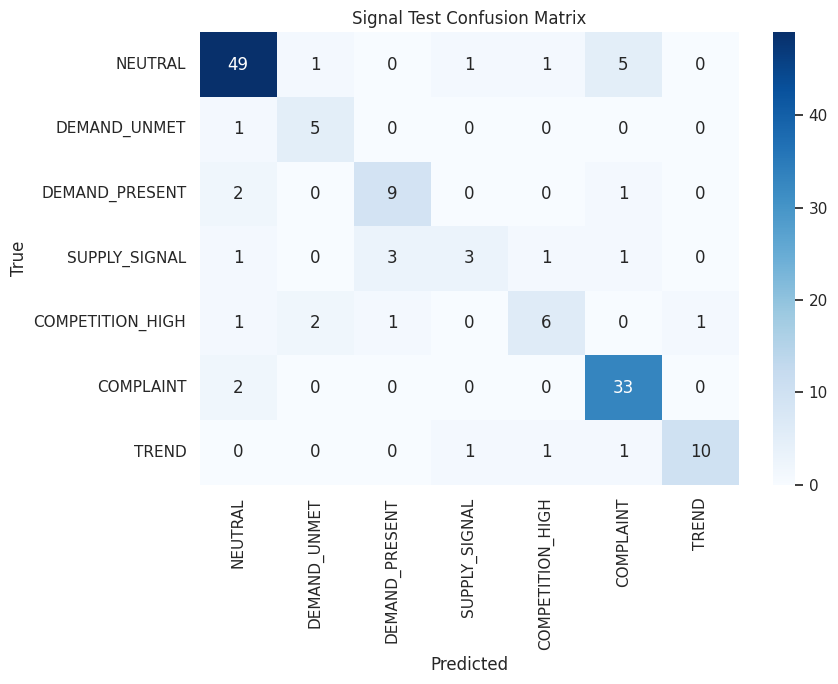

,precision,recall,f1-score,support
NEUTRAL,0.875000,0.859649,0.867257,57.000000
DEMAND_UNMET,0.625000,0.833333,0.714286,6.000000
DEMAND_PRESENT,0.692308,0.750000,0.720000,12.000000
SUPPLY_SIGNAL,0.600000,0.333333,0.428571,9.000000
COMPETITION_HIGH,0.666667,0.545455,0.600000,11.000000
COMPLAINT,0.804878,0.942857,0.868421,35.000000
TREND,0.909091,0.769231,0.833333,13.000000
accuracy,0.804196,0.804196,0.804196,0.804196
macro avg,0.738992,0.719123,0.718838,143.000000
weighted avg,0.801783,0.804196,0.797514,143.000000


,text,top_label,top_probability,runner_up
0,sudah pada nyobain guys kuliner malang kulinermalang bakmi mie,DEMAND_PRESENT,0.9386,COMPETITION_HIGH
1,jangan lebay tapi ini mala nya balance kuliner malang kulinermalang mie noodles mala pedas spicy mbakbulekulineran,DEMAND_PRESENT,0.9428,NEUTRAL
2,cocok banget pas malang lagi ujan kulinermalang kulinermalangraya mahasiswamalang pangsitmiesenja pangsitmalang,SUPPLY_SIGNAL,0.3781,DEMAND_PRESENT
3,"menu ramyeon tray topping baru haus kali ini benar benerrr enakkk, dan perlu dicoba untuk add on mozzarella nya!!!",DEMAND_PRESENT,0.5834,NEUTRAL
4,"mie ayam porsi barbar, harga mulai 10 ribu saja mie ayam sam edy jl.",COMPETITION_HIGH,0.5219,NEUTRAL
5,"rasanya nikmatt, porsi buanyakk sangat untuk kalian yang suka chinese food yukk cobain depot fyp makananviral malang24ja",TREND,0.9949,COMPLAINT
6,"lowokwaru, kota malang, jawa timur 65149 lalapan lalapanmalang lalapanmurahmalang",COMPETITION_HIGH,0.9150,SUPPLY_SIGNAL
7,banyak yang balik lagi karena rasanya ayam crispy dengan saus khas jatinangor yang gurih dan konsisten.,COMPETITION_HIGH,0.3963,NEUTRAL
8,"cocok untuk kalian yang cari tempat estetik, fancy, elegan, dan minum-minum cantik.",NEUTRAL,0.7371,SUPPLY_SIGNAL
9,"warung ijo depan pom bensin, jl. argolubang, baciro, kec. gondokusuman, kota yogyakarta, daerah istimewa yogyakarta 5522",DEMAND_UNMET,0.9836,TREND


,macro_f1,weighted_f1,accuracy,samples,label_column
0,0.718838,0.797514,0.804196,143,final_signal


In [10]:
signal_report_df, signal_preview_df, signal_eval_metrics = evaluate_signal_checkpoint(
    REPO_ROOT / "models" / "signal_base",
    REPO_ROOT / "test_data" / "signal_test.csv",
)
display(signal_report_df)
display(signal_preview_df)
display(pd.DataFrame([signal_eval_metrics]))


The signal model is only as strong as the supervision it sees.
This report is the honest checkpoint that should drive README claims, not any earlier experiment that used a different data regime.


If a manually reviewed signal gold set exists, evaluate it separately here.
That keeps the notebook honest about the difference between a weak-label diagnostic split and the production gate.


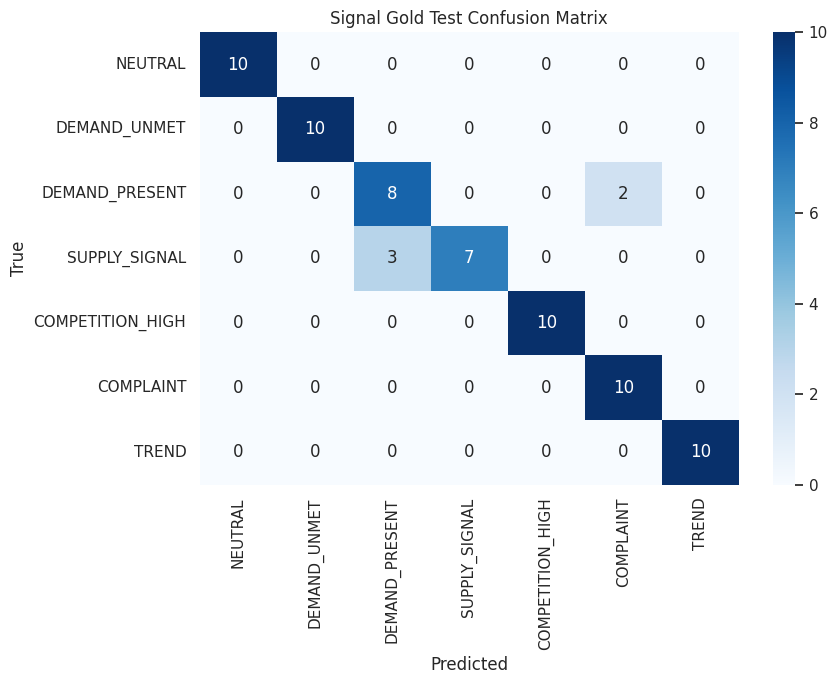

,precision,recall,f1-score,support
NEUTRAL,1.000000,1.000000,1.000000,10.000000
DEMAND_UNMET,1.000000,1.000000,1.000000,10.000000
DEMAND_PRESENT,0.727273,0.800000,0.761905,10.000000
SUPPLY_SIGNAL,1.000000,0.700000,0.823529,10.000000
COMPETITION_HIGH,1.000000,1.000000,1.000000,10.000000
COMPLAINT,0.833333,1.000000,0.909091,10.000000
TREND,1.000000,1.000000,1.000000,10.000000
accuracy,0.928571,0.928571,0.928571,0.928571
macro avg,0.937229,0.928571,0.927789,70.000000
weighted avg,0.937229,0.928571,0.927789,70.000000


,text,top_label,top_probability,runner_up
0,"cocok untuk kalian yang cari tempat estetik, fancy, elegan, dan minum-minum cantik.",NEUTRAL,0.7371,SUPPLY_SIGNAL
1,setail - wonokromo - surabaya vibes kekeluargaan dan ambyarnya dapet banget.,NEUTRAL,0.9910,DEMAND_PRESENT
2,persiapan untuk buka bersama nih cocok banget tempatnya,NEUTRAL,0.9656,DEMAND_PRESENT
3,"iya juga ini saya baru nyampe indonesia, langsung cepet2 untuk reservasi inget!",NEUTRAL,0.9890,DEMAND_PRESENT
4,onni house surabaya loc jl.,NEUTRAL,0.9705,TREND
5,upload video makanan dan minuman kamu membuat ulang menu di bawah ini dengan hashtag menuviral serunyakuliner - seblak r,NEUTRAL,0.9885,DEMAND_UNMET
6,upload minimal 5 video sesuai dengan ketentuan poin 1 untuk bisa mengikuti kompetisi.,NEUTRAL,0.9835,DEMAND_PRESENT
7,nih kita kasih yang masih muda tapi matang,NEUTRAL,0.9865,DEMAND_UNMET
8,"uniknya rawon disini, dia itu tidak pake daging yang kaya biasanya, tapi bisa pilih mau krengsengan / suwir / iga / apap",NEUTRAL,0.9870,COMPETITION_HIGH
9,ini saya pesen lauk campur dan minta kuahnya dipisah..,NEUTRAL,0.9930,DEMAND_UNMET


,macro_f1,weighted_f1,accuracy,samples,label_column
0,0.927789,0.927789,0.928571,70,gold_label


In [11]:
signal_gold_metrics = None
gold_signal_df = load_completed_gold_signal_set(MANUAL_SIGNAL_TEST_FILE)
if gold_signal_df.empty:
    print(f"No completed manual gold signal set found at {MANUAL_SIGNAL_TEST_FILE}")
else:
    gold_signal_path = REPO_ROOT / "test_data" / "signal_test_manual_completed.csv"
    gold_signal_df.to_csv(gold_signal_path, index=False)
    gold_report_df, gold_preview_df, signal_gold_metrics = evaluate_signal_checkpoint(
        REPO_ROOT / "models" / "signal_base",
        gold_signal_path,
        label_column="gold_label",
        metrics_filename="signal_test_metrics_gold.json",
        confusion_title="Signal Gold Test Confusion Matrix",
    )
    display(gold_report_df)
    display(gold_preview_df)
    display(pd.DataFrame([signal_gold_metrics]))


In [12]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

run_command([sys.executable, "02_ner_model/modelling/train.py"])
ner_metrics = read_json(REPO_ROOT / "logs" / "ner_training_metrics.json")
display(pd.DataFrame([ner_metrics]))


$ /home/parasite/Project/Competition/UGM_HACKATHON/.venv/bin/python 02_ner_model/modelling/train.py


 NER Model Training — LokaSense
  Train: 3453 | Val: 400
  Labels (7): ['B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER', 'O']
{'loss': 0.8842, 'grad_norm': 1.952630639076233, 'learning_rate': 1.416184971098266e-05, 'epoch': 0.23}
{'loss': 0.2336, 'grad_norm': 4.972861289978027, 'learning_rate': 2.861271676300578e-05, 'epoch': 0.46}
{'loss': 0.1477, 'grad_norm': 1.964234471321106, 'learning_rate': 4.3063583815028904e-05, 'epoch': 0.69}
{'loss': 0.1404, 'grad_norm': 1.1945689916610718, 'learning_rate': 4.9163987138263665e-05, 'epoch': 0.93}
{'eval_loss': 0.11001183837652206, 'eval_ner_f1': 0.7637370495012616, 'eval_runtime': 0.8098, 'eval_samples_per_second': 493.938, 'eval_steps_per_second': 123.484, 'epoch': 1.0}
{'loss': 0.1269, 'grad_norm': 2.858705759048462, 'learning_rate': 4.755627009646302e-05, 'epoch': 1.16}
{'loss': 0.0908, 'grad_norm': 1.779653787612915, 'learning_rate': 4.594855305466238e-05, 'epoch': 1.39}
{'loss': 0.0796, 'grad_norm': 1.2949179410934448, 'learning_rate

,training_time_sec,train_loss,best_metric,label_count,labels
0,368.130549,0.06608,0.866113,7,"[B-LOC, B-ORG, B-PER, I-LOC, I-ORG, I-PER, O]"


The NER path is trained after the signal model so both artifacts are refreshed inside one notebook run.


In [13]:
ner_report_df, ner_preview_df, ner_eval_metrics = evaluate_ner_checkpoint(
    REPO_ROOT / "models" / "ner_base",
    REPO_ROOT / "test_data" / "ner_test.json",
)
display(ner_report_df)
display(ner_preview_df)
display(pd.DataFrame([ner_eval_metrics]))


,precision,recall,f1-score,support
LOC,0.747851,0.805556,0.775632,324.0
ORG,0.641463,0.751429,0.692105,350.0
PER,0.868263,0.891393,0.879676,488.0
micro avg,0.761111,0.825301,0.791908,1162.0
macro avg,0.752526,0.816126,0.782471,1162.0
weighted avg,0.766376,0.825301,0.794168,1162.0


,text,gold_entities,pred_entities
0,Langsat dipatok Rp 4 - 6 ribu dari Rp 10 ribu .,[],[]
1,"PTBA juga telah merelokasi beberapa fasilitas tambang seperti pool kendaraan , kantor K-3 , laboratorium mekanika batuan","[{'entity': 'PTBA', 'label': 'ORG'}]","[{'entity': 'PTBA', 'label': 'ORG'}]"
2,Hal yang utama adalah pengaplikasian Airport Operation Data Base ( AODB ) dimana operasional bandara disesuaikan dengan,[],[]
3,"Menurut Johan , laporan hasil analisis merupakan bahan mentah , sehingga KPK tidak bisa langsung melanjutkan ke proses p","[{'entity': 'Johan', 'label': 'PER'}]","[{'entity': 'Johan', 'label': 'PER'}, {'entity': 'KPK', 'label': 'ORG'}]"
4,Tradisi yang dimaksud adalah memberikan kewenangan kepada pengurus daerah memutuskan pencalonan bupati atau wali kota se,[],[]
5,"Menurut Priyo , evaluasi terhadap Ical akan terjadi jika perolehan suara pada pemilu legislatif jauh dari angka yang dit","[{'entity': 'Priyo', 'label': 'PER'}]","[{'entity': 'Priyo', 'label': 'PER'}]"
6,""" Warga setempat akan lebih mudah mengidentifikasi fitur kota daripada mereka yang tidak tinggal di sana , "" kata Sanche","[{'entity': 'Sanchez', 'label': 'PER'}]","[{'entity': 'Sanchez', 'label': 'PER'}]"
7,"Menteri Kelautan dan Perikanan juga mengatakan , atas kontribusi masyarakat itulah luas kawasan konservasi Raja Ampat di","[{'entity': 'Raja Ampat', 'label': 'LOC'}]","[{'entity': 'Raja Ampat', 'label': 'LOC'}]"


,micro_f1,samples
0,0.791908,682


The NER preview is useful as a qualitative sanity check because it exposes whether the model is actually extracting entity spans instead of only posting a decent aggregate F1.


In [14]:
scoring_input_df = predict_signal_dataframe(
    REPO_ROOT / "models" / "signal_base",
    pd.read_csv(signal_bootstrap_path),
)
poi_file = REPO_ROOT / "data" / "poi" / "overpass_poi.csv"
poi_df = pd.read_csv(poi_file) if poi_file.exists() else None
scores_df = spatial_scoring.compute_opportunity_scores(scoring_input_df, poi_df=poi_df, resolver=LocationResolver())
if not scores_df.empty and "opportunity_score" in scores_df.columns:
    display(scores_df.sort_values("opportunity_score", ascending=False).head(20))
else:
    print("No opportunity groups met the scoring threshold yet.")

heatmap_output = REPO_ROOT / "outputs" / "lokasense_heatmap.html"
marker_map = spatial_heatmap.create_marker_map(scores_df)
marker_map.save(str(heatmap_output))
print(f"Heatmap written to {heatmap_output}")


Scored 24 area x business combinations


,city,kecamatan,business_type,opportunity_score,color,label,total_signals,signal_breakdown,raw_signal_score,raw_score_after_penalty,franchise_ratio,avg_age_days,avg_decay_weight,resolved_lat,resolved_lng,resolution_source
11,Semarang,Gajahmungkur,ayam bakar,1.000,green,Strong Opportunity,5,{'DEMAND_UNMET': 5},0.3000,0.3000,0.0,178.69,0.0967,-7.009682,110.404685,area_centroid
2,Bandung,Lengkong,kopi,0.981,green,Strong Opportunity,16,"{'DEMAND_UNMET': 15, 'TREND': 1}",0.2884,0.2884,0.0,175.65,0.2128,-6.928765,107.619587,area_centroid
19,Yogyakarta,Gondokusuman,warung makan,0.973,green,Strong Opportunity,17,"{'DEMAND_UNMET': 14, 'SUPPLY_SIGNAL': 2, 'TREND': 1}",0.2840,0.2840,0.0,273.70,0.0731,-7.785633,110.382189,area_centroid
0,Bandung,Cicendo,kopi,0.928,green,Strong Opportunity,16,"{'DEMAND_UNMET': 11, 'TREND': 3, 'DEMAND_PRESENT': 2}",0.2568,0.2568,0.0,51.57,0.5529,-6.905082,107.592185,area_centroid
12,Semarang,Gajahmungkur,kuliner,0.764,green,Strong Opportunity,12,"{'DEMAND_UNMET': 8, 'DEMAND_PRESENT': 2, 'NEUTRAL': 1, 'TREND': 1}",0.1584,0.1584,0.0,127.75,0.2692,-7.009682,110.404685,area_centroid
23,Yogyakarta,Umbulharjo,mie,0.728,green,Strong Opportunity,18,"{'NEUTRAL': 9, 'DEMAND_UNMET': 3, 'TREND': 3, 'DEMAND_PRESENT': 2, 'COMPETITION_HIGH': 1}",0.1366,0.1366,0.0,217.50,0.1249,-7.813068,110.385494,area_centroid
13,Surabaya,Genteng,soto,0.697,green,Strong Opportunity,16,"{'TREND': 13, 'DEMAND_PRESENT': 1, 'COMPETITION_HIGH': 1, 'DEMAND_UNMET': 1}",0.1181,0.1181,0.0,127.41,0.4237,-7.260760,112.744467,area_centroid
7,Malang,Klojen,nasi padang,0.671,green,Strong Opportunity,6,"{'DEMAND_PRESENT': 3, 'TREND': 2, 'SUPPLY_SIGNAL': 1}",0.1028,0.1028,0.0,88.63,0.3696,-7.973856,112.627379,area_centroid
5,Malang,Kedungkandang,ayam bakar,0.671,green,Strong Opportunity,13,"{'DEMAND_PRESENT': 7, 'COMPETITION_HIGH': 4, 'DEMAND_UNMET': 2}",0.1027,0.1027,0.0,78.68,0.3634,-7.988064,112.654722,area_centroid
1,Bandung,Lengkong,es teh,0.667,green,Strong Opportunity,11,{'TREND': 11},0.1000,0.1000,0.0,145.82,0.2183,-6.928765,107.619587,area_centroid


Heatmap written to /home/parasite/Project/Competition/UGM_HACKATHON/outputs/lokasense_heatmap.html


This cell exercises the scoring path exactly the way a production batch would use it: model predictions, time-decay weighting, franchise penalties, and resolved coordinates.


In [15]:
readiness_checks = [
    {"check": "free_by_default", "passed": True, "details": "Notebook did not run Google Maps refresh."},
    {"check": "train_test_leakage_zero", "passed": leakage_count == 0, "details": leakage_count},
    {
        "check": "signal_train_rows",
        "passed": int(pd.read_csv(signal_split_paths["train"]).shape[0]) >= READINESS_THRESHOLDS["signal_train_rows"],
        "details": int(pd.read_csv(signal_split_paths["train"]).shape[0]),
    },
    {
        "check": "signal_macro_f1",
        "passed": float(signal_eval_metrics["macro_f1"]) >= READINESS_THRESHOLDS["signal_eval_macro_f1"],
        "details": float(signal_eval_metrics["macro_f1"]),
    },
    {
        "check": "signal_gold_set_present",
        "passed": signal_gold_metrics is not None,
        "details": int(signal_gold_metrics["samples"]) if signal_gold_metrics else 0,
    },
    {
        "check": "signal_gold_macro_f1",
        "passed": signal_gold_metrics is not None and float(signal_gold_metrics["macro_f1"]) >= READINESS_THRESHOLDS["signal_gold_macro_f1"],
        "details": float(signal_gold_metrics["macro_f1"]) if signal_gold_metrics else 0.0,
    },
    {
        "check": "ner_micro_f1",
        "passed": float(ner_eval_metrics["micro_f1"]) >= READINESS_THRESHOLDS["ner_eval_micro_f1"],
        "details": float(ner_eval_metrics["micro_f1"]),
    },
    {
        "check": "opportunity_groups",
        "passed": int(len(scores_df)) >= READINESS_THRESHOLDS["opportunity_groups"],
        "details": int(len(scores_df)),
    },
    {
        "check": "all_signal_classes_seen_in_train",
        "passed": set(signal_distribution_df.index[signal_distribution_df["train"] > 0]) == set(SIGNAL_LABELS),
        "details": int((signal_distribution_df["train"] > 0).sum()),
    },
]

failed_checks = [check["check"] for check in readiness_checks if not check["passed"]]
readiness_status = "ready" if not failed_checks else "not_ready"
readiness_payload = {
    "status": readiness_status,
    "failed_checks": failed_checks,
    "checks": readiness_checks,
    "thresholds": READINESS_THRESHOLDS,
    "signal_metrics": signal_eval_metrics,
    "signal_gold_metrics": signal_gold_metrics,
    "ner_metrics": ner_eval_metrics,
    "opportunity_groups": int(len(scores_df)),
}

readiness_path = REPO_ROOT / "logs" / "production_readiness.json"
with open(readiness_path, "w", encoding="utf-8") as handle:
    json.dump(readiness_payload, handle, indent=2)

display(pd.DataFrame(readiness_checks))
display(pd.DataFrame([{"production_status": readiness_status, "failed_checks": ", ".join(failed_checks)}]))
print(f"Readiness report written to {readiness_path}")


,check,passed,details
0,free_by_default,True,Notebook did not run Google Maps refresh.
1,train_test_leakage_zero,True,0
2,signal_train_rows,True,1105
3,signal_macro_f1,True,0.718838
4,signal_gold_set_present,True,70
5,signal_gold_macro_f1,True,0.927789
6,ner_micro_f1,True,0.791908
7,opportunity_groups,True,24
8,all_signal_classes_seen_in_train,True,7


,production_status,failed_checks
0,ready,


Readiness report written to /home/parasite/Project/Competition/UGM_HACKATHON/logs/production_readiness.json


The readiness summary is the production guardrail.
If the signal dataset is still too small or the evaluated metrics are still below threshold, the notebook should say so explicitly instead of pretending the pipeline is ready for deployment.


In [16]:
summary_rows = [
    {"artifact": "signal_bootstrap", "path": str(REPO_ROOT / "data" / "scraped" / "signal_bootstrap.csv")},
    {"artifact": "ner_bootstrap", "path": str(REPO_ROOT / "data" / "scraped" / "ner_bootstrap.jsonl")},
    {"artifact": "signal_model", "path": str(REPO_ROOT / "models" / "signal_base")},
    {"artifact": "ner_model", "path": str(REPO_ROOT / "models" / "ner_base")},
    {"artifact": "signal_training_metrics", "path": str(REPO_ROOT / "logs" / "signal_training_metrics.json")},
    {"artifact": "ner_training_metrics", "path": str(REPO_ROOT / "logs" / "ner_training_metrics.json")},
    {"artifact": "signal_test_metrics_pytorch", "path": str(REPO_ROOT / "logs" / "signal_test_metrics_pytorch.json")},
    {"artifact": "signal_test_metrics_gold", "path": str(REPO_ROOT / "logs" / "signal_test_metrics_gold.json")},
    {"artifact": "ner_test_metrics_pytorch", "path": str(REPO_ROOT / "logs" / "ner_test_metrics_pytorch.json")},
    {"artifact": "opportunity_scores", "path": str(REPO_ROOT / "logs" / "opportunity_scores.csv")},
    {"artifact": "production_readiness", "path": str(REPO_ROOT / "logs" / "production_readiness.json")},
    {"artifact": "heatmap", "path": str(REPO_ROOT / "outputs" / "lokasense_heatmap.html")},
]
display(pd.DataFrame(summary_rows))


,artifact,path
0,signal_bootstrap,/home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/signal_bootstrap.csv
1,ner_bootstrap,/home/parasite/Project/Competition/UGM_HACKATHON/data/scraped/ner_bootstrap.jsonl
2,signal_model,/home/parasite/Project/Competition/UGM_HACKATHON/models/signal_base
3,ner_model,/home/parasite/Project/Competition/UGM_HACKATHON/models/ner_base
4,signal_training_metrics,/home/parasite/Project/Competition/UGM_HACKATHON/logs/signal_training_metrics.json
5,ner_training_metrics,/home/parasite/Project/Competition/UGM_HACKATHON/logs/ner_training_metrics.json
6,signal_test_metrics_pytorch,/home/parasite/Project/Competition/UGM_HACKATHON/logs/signal_test_metrics_pytorch.json
7,signal_test_metrics_gold,/home/parasite/Project/Competition/UGM_HACKATHON/logs/signal_test_metrics_gold.json
8,ner_test_metrics_pytorch,/home/parasite/Project/Competition/UGM_HACKATHON/logs/ner_test_metrics_pytorch.json
9,opportunity_scores,/home/parasite/Project/Competition/UGM_HACKATHON/logs/opportunity_scores.csv
